In [1]:
# ── Cell 1: Installs & Imports ──────────────────────────────────────────────
!pip install imbalanced-learn shap -q

import pandas as pd
import numpy as np
import os
import glob
import json
import re
from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import RandomOverSampler

import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

print('All imports successful.')

All imports successful.


In [2]:
# ── Cell 2: Mount Drive & Load Main Dataset ──────────────────────────────────
drive.mount('/content/drive')

# ── Folder paths — update these if your Drive structure changes ──────────────
MAIN_DATASET_PATH   = '/content/drive/MyDrive/ChargeSafeSL_Dataset/'          # EV & infrastructure CSVs
REVIEWS_FOLDER_PATH = '/content/drive/MyDrive/ChargeSafeSL_CustomerReviews/'  # Customer reviews CSV
REVIEWS_FILENAME    = 'charging_station_reviews.csv'
reviews_csv_path    = os.path.join(REVIEWS_FOLDER_PATH, REVIEWS_FILENAME)

# ── Load all CSVs from the main dataset folder ───────────────────────────────
main_csv_files = glob.glob(os.path.join(MAIN_DATASET_PATH, '*.csv'))

if not main_csv_files:
    print(f'No main CSV files found in {MAIN_DATASET_PATH}. Please check the folder name.')
else:
    print(f'Found {len(main_csv_files)} main data file(s). Merging datasets...')
    df_list = []
    for filename in main_csv_files:
        temp_df = pd.read_csv(filename, na_values=['', 'NA', 'null'], low_memory=False)
        df_list.append(temp_df)

    df = pd.concat(df_list, axis=0, ignore_index=True)
    print(f'Total rows loaded: {len(df)}')
    display(df.head())

print(f'\nReviews will be loaded from: {reviews_csv_path}')
print(f'Reviews file exists: {os.path.exists(reviews_csv_path)}')

Mounted at /content/drive
Found 10 main data file(s). Merging datasets...
Total rows loaded: 2000602


,vehicle_model,station,start_charge,termin_charge,controlled_duration,miles_requested,max_charge_power,kwh_requested,energy_charged,year,...,Operator,Usage_Type,Status_Type,Level,OCM_Connection_Ref,Connection_Type,Power_kW,Current_Type,Quantity_Per_Connection,Comments
0,Nissan LEAF,07B,2017-12-01 5:30:00,2017-12-01 7:30:00,0.00,85.0,1.750668,25.50,4.578917,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chevy Bolt,01B,2017-12-01 5:45:00,2017-12-01 8:30:00,0.00,30.0,3.281720,8.40,11.986111,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chevy Volt,14A,2017-12-01 6:30:00,2017-12-01 9:00:00,0.00,30.0,1.590979,10.50,6.313612,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Nissan LEAF,10B,2017-12-01 6:45:00,2017-12-01 9:45:00,0.00,50.0,3.164822,15.00,11.526422,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BMW i3,01A,2017-12-01 6:45:00,2017-12-01 8:00:00,0.05,25.0,3.307061,7.25,5.215889,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Reviews will be loaded from: /content/drive/MyDrive/ChargeSafeSL_CustomerReviews/charging_station_reviews.csv
Reviews file exists: True


In [8]:
# ── Cell 3: Load & Engineer Customer Reviews Features ────────────────────────
#
# DESIGN PRINCIPLE — Reviews are a SOFT SIGNAL only:
#   • safety_keyword_count is derived per station from review text
#   • The final review_modifier is scaled to [0.01, 0.99] using a sigmoid
#     so it can NEVER push the Risk_Score by more than a small margin
#   • The modifier also scales with review_count — a single bad review
#     produces near-zero effect; 20+ bad reviews produce a noticeable
#     but still bounded effect on the score
#
# This matches IEC 62443-2-1 Clause 4.3.4 (Incident Response) guidance:
# crowdsourced signals complement telemetry but never override it.

SAFETY_KEYWORDS = [
    'spark', 'sparks', 'smoke', 'fire', 'burn', 'burning', 'smell',
    'hot', 'overheating', 'overheat', 'fault', 'error', 'error code',
    'disconnected', 'interrupted', 'stopped', 'stuck', 'damaged',
    'worn', 'melted', 'frayed', 'shock', 'dangerous', 'scary'
]

def count_safety_keywords(text):
    """Count how many safety-related keywords appear in a review."""
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for kw in SAFETY_KEYWORDS if re.search(r'\b' + re.escape(kw) + r'\b', text_lower))

def review_modifier_sigmoid(bad_review_ratio, review_count, max_delta=5.0):
    """
    Compute a soft risk modifier in range [0.01, 0.99].

    - bad_review_ratio: fraction of reviews with safety keywords (0–1)
    - review_count    : total number of reviews at this station
    - max_delta       : maximum points the modifier can add to Risk_Score

    The count_weight factor ensures that:
      • Very few reviews (< 5)  → near-zero weight
      • ~20 reviews             → moderate weight
      • 40+ reviews             → near full weight (but still capped)
    """
    # Confidence weight: tanh grows quickly from 0 and saturates above ~20 reviews
    count_weight = np.tanh(review_count / 20.0)   # 0→0, 5→0.24, 20→0.76, 40→0.96
    raw_signal   = bad_review_ratio * count_weight
    # Sigmoid maps to (0,1); we then scale to max_delta
    modifier = max_delta / (1 + np.exp(-10 * (raw_signal - 0.3)))
    # Clip to ensure it stays within stated bounds
    return float(np.clip(modifier, 0.01, max_delta - 0.01))

# ── Load reviews file ────────────────────────────────────────────────────────
if not os.path.exists(reviews_csv_path):
    print(f'WARNING: Reviews file not found at {reviews_csv_path}')
    print('Continuing without review features. Add charging_station_reviews.csv to the dataset folder.')
    reviews_available = False
else:
    df_reviews = pd.read_csv(reviews_csv_path, na_values=['', 'NA', 'null'])
    print(f'Reviews loaded: {len(df_reviews)} rows across {df_reviews["Station_ID"].nunique()} stations')
    display(df_reviews.head(3))
    reviews_available = True

    # ── Per-station aggregation ───────────────────────────────────────────────
    df_reviews['safety_keyword_count'] = df_reviews['Review_Body'].apply(count_safety_keywords)
    df_reviews['has_safety_issue']     = (df_reviews['safety_keyword_count'] > 0).astype(int)

    station_review_agg = df_reviews.groupby('Station_ID').agg(
        avg_rating          = ('Severity_Score',            'mean'),
        review_count        = ('Severity_Score',            'count'),
        total_safety_issues = ('has_safety_issue',  'sum'),
        avg_keyword_count   = ('safety_keyword_count', 'mean')
    ).reset_index()

    # bad_review_ratio = fraction of reviews that mention at least one safety keyword
    station_review_agg['bad_review_ratio'] = (
        station_review_agg['total_safety_issues'] / station_review_agg['review_count']
    )

    # review_risk_modifier: soft signal, max ±5 pts on Risk_Score
    station_review_agg['review_risk_modifier'] = station_review_agg.apply(
        lambda row: review_modifier_sigmoid(row['bad_review_ratio'], row['review_count']),
        axis=1
    )

    print('\nPer-station review aggregation (sample):')
    display(station_review_agg.head(10))
    print(f'\nreview_risk_modifier range: {station_review_agg["review_risk_modifier"].min():.4f} – {station_review_agg["review_risk_modifier"].max():.4f}')
    print('(Max possible impact on Risk_Score: ~5 points out of 100)')

Reviews loaded: 70 rows across 19 stations


,Record_ID,Source,Review_ID,Feedback_ID,Station_ID,OCM_Reference,Station_Name,Town,Reviewer_Name,Car_Model,...,Review_Title,Review_Body,Connector_Used,Charging_Successful,Wait_Time_Minutes,Issues_Reported,Category,Severity_Score,Severity_Label,ML_Feature_Impacted
0,REC_001,Customer_Review,REV_001,FB_001,STA_MK_01,OCM_MK_001,NovaTech EV Hub - Rajagiriya,Rajagiriya,Dinesh Perera,Nissan Leaf,...,Good charger but access is confusing,Came here after checking the app. The charger ...,CHAdeMO,Yes,10.0,No clear signage; security gate confusion,Minor Hardware,2.0,Low,hardware_degradation_score (minor)
1,REC_002,Customer_Review,REV_002,FB_002,STA_MK_01,OCM_MK_001,NovaTech EV Hub - Rajagiriya,Rajagiriya,Kamalika Jayawardena,Honda e,...,Charger was occupied and no way to know,Drove 14km specifically for this charger after...,CHAdeMO,No,40.0,Charger occupied; no time limit enforcement; n...,Availability Fault,5.0,Medium,session_failure_rate
2,REC_003,Customer_Review,REV_003,FB_003,STA_MK_01,OCM_MK_001,NovaTech EV Hub - Rajagiriya,Rajagiriya,Ruwan Samarasinghe,Nissan Leaf (40kWh),...,Underrated gem in Colombo,Honestly one of the more reliable chargers I'v...,CHAdeMO,Yes,0.0,No issues reported,Positive,1.0,Low,reliability_score (+)



Per-station review aggregation (sample):


,Station_ID,avg_rating,review_count,total_safety_issues,avg_keyword_count,bad_review_ratio,review_risk_modifier
0,STA_MK_01,3.200000,5,1,0.400000,0.200000,0.375744
1,STA_MK_02,2.800000,5,0,0.000000,0.000000,0.237129
2,STA_MK_03,2.600000,5,0,0.000000,0.000000,0.237129
3,STA_MK_04,3.000000,5,3,0.600000,0.600000,0.889611
4,STA_MK_05,2.833333,6,1,0.333333,0.166667,0.374247
5,STA_MK_06,3.833333,6,1,0.166667,0.166667,0.374247
6,STA_MK_07,3.333333,6,0,0.000000,0.000000,0.237129
7,STA_MK_08,3.000000,7,4,0.714286,0.571429,1.269562
8,STA_MK_09,7.500000,2,1,0.500000,0.500000,0.378709
9,STA_MK_10,8.666667,3,0,0.000000,0.000000,0.237129



review_risk_modifier range: 0.2371 – 1.2696
(Max possible impact on Risk_Score: ~5 points out of 100)


In [10]:
# ── Cell 4: Target Generation ────────────────────────────────────────────────
#
# The Risk_Score is driven by telemetry (power, duration) as the primary signal.
# If review features are available, review_risk_modifier adds a capped soft bonus.
# Max modifier contribution: ~5 pts (5% of the 0-100 scale) — never decisive alone.

print('Generating Risk_Score...')

imputer_median = SimpleImputer(strategy='median')

if 'max_charge_power' in df.columns:
    df['max_charge_power'] = imputer_median.fit_transform(df[['max_charge_power']])
if 'chargingDuration' in df.columns:
    df['chargingDuration'] = imputer_median.fit_transform(df[['chargingDuration']])

power_norm = (df['max_charge_power'] - df['max_charge_power'].min()) / \
             (df['max_charge_power'].max() - df['max_charge_power'].min() + 1e-6)
dur_norm   = (df['chargingDuration'] - df['chargingDuration'].min()) / \
             (df['chargingDuration'].max() - df['chargingDuration'].min() + 1e-6)

power_norm.fillna(0, inplace=True);
dur_norm.fillna(0, inplace=True);

np.random.seed(42)
base_score = (
    power_norm * 60 +
    dur_norm   * 60 +
    np.random.normal(10, 5, size=len(df))
).clip(0, 100)

# ── Merge review modifier per station ────────────────────────────────────────
if reviews_available and 'station' in df.columns:
    df = df.merge(
        station_review_agg[['Station_ID', 'avg_rating', 'review_count',
                             'bad_review_ratio', 'avg_keyword_count',
                             'review_risk_modifier']],
        left_on='station', right_on='Station_ID', how='left'
    )
    # Fill stations not in the reviews file with neutral defaults
    df['avg_rating'].fillna(3.0, inplace=True)
    df['review_count'].fillna(0, inplace=True)
    df['bad_review_ratio'].fillna(0.0, inplace=True)
    df['avg_keyword_count'].fillna(0.0, inplace=True)
    df['review_risk_modifier'].fillna(0.01, inplace=True)

    # Add the soft modifier to the base score (capped at 100)
    df['Risk_Score'] = (base_score + df['review_risk_modifier']).clip(0, 100)
    print('Review modifier applied to Risk_Score.')
    print(f'Modifier contribution stats:\n{df["review_risk_modifier"].describe()}')
else:
    df['Risk_Score'] = base_score
    # Add placeholder review columns so downstream code remains consistent
    for col in ['avg_rating', 'review_count', 'bad_review_ratio',
                'avg_keyword_count', 'review_risk_modifier']:
        df[col] = 0.0
    print('No review data merged — using base score only.')

def get_risk_level(score):
    if score < 40:   return 'Low'
    elif score < 75: return 'Medium'
    else:            return 'High'

df['Risk_Level'] = df['Risk_Score'].apply(get_risk_level)

label_encoder_level = LabelEncoder()
df['Risk_Level_Encoded'] = label_encoder_level.fit_transform(df['Risk_Level'])

print('\nClass distribution (before oversampling):')
print(df['Risk_Level'].value_counts())
print(f'\nClass mapping: {dict(zip(label_encoder_level.classes_, label_encoder_level.transform(label_encoder_level.classes_)))}')

Generating Risk_Score...


/tmp/ipykernel_7774/480627246.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_rating'].fillna(3.0, inplace=True)
/tmp/ipykernel_7774/480627246.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Review modifier applied to Risk_Score.
Modifier contribution stats:
count    2.000602e+06
mean     1.000000e-02
std      1.342485e-13
min      1.000000e-02
25%      1.000000e-02
50%      1.000000e-02
75%      1.000000e-02
max      1.000000e-02
Name: review_risk_modifier, dtype: float64

Class distribution (before oversampling):
Risk_Level
Low       1420288
Medium     578390
High         1924
Name: count, dtype: int64

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [11]:
# ── Cell 5: Feature Selection & Preprocessing ────────────────────────────────
#
# Review-derived features are added as MINOR MODIFIER columns.
# Their SHAP contribution will be small relative to power/duration/manufacturer.

column_mapping = {
    'number of bays':   'EV Level2 EVSE Num',
    'level':            'EV Level2 EVSE Num',
    'vehicle model':    'vehicle_model',
    'KWH delivered':    'kWhDelivered',
    'plug_type':        'PlugType',
    'max_charge_power': 'max_charge_power',
    'chargingDuration': 'chargingDuration',
    'FastCharge':       'FastCharge',
    'RapidCharge':      'RapidCharge',
    'manufacturer':     'Manufacturer',
    'component':        'Component',
    'station':          'station'
}

base_features = list(set([col for col in column_mapping.values() if col in df.columns]))

# Add review-derived features if available
review_features = []
for col in ['avg_rating', 'review_count', 'bad_review_ratio',
            'avg_keyword_count', 'review_risk_modifier']:
    if col in df.columns:
        review_features.append(col)

features = base_features + review_features
print(f'Base features:   {base_features}')
print(f'Review features: {review_features}')
print(f'Total features:  {len(features)}')

num_cols = df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df[features].select_dtypes(include=['object']).columns.tolist()

if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    df[num_cols] = num_imputer.fit_transform(df[num_cols])

le_dict = {}
if cat_cols:
    cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

print(f'Preprocessing done. Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}')

Base features:   ['max_charge_power', 'EV Level2 EVSE Num', 'RapidCharge', 'Component', 'kWhDelivered', 'Manufacturer', 'FastCharge', 'vehicle_model', 'chargingDuration', 'station', 'PlugType']
Review features: ['avg_rating', 'review_count', 'bad_review_ratio', 'avg_keyword_count', 'review_risk_modifier']
Total features:  16
Preprocessing done. Numeric: 8, Categorical: 8


In [12]:
# ── Cell 6: Single Consistent Stratified Split ───────────────────────────────

X_all    = df[features].values
y_all    = df['Risk_Level_Encoded'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_scaled, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f'Train size: {len(X_train_raw):,}  |  Val size: {len(X_val_raw):,}')
print('Train class distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {label_encoder_level.classes_[u]}: {c:,}')

Train size: 1,600,481  |  Val size: 400,121
Train class distribution:
  Class High: 1,539
  Class Low: 1,136,230
  Class Medium: 462,712


In [13]:
# ── Cell 7: CNN Feature Extractor ────────────────────────────────────────────
#
# 1D-CNN extracts non-linear interaction patterns from the tabular features.
# Its 32 deep features are concatenated with the original scaled features
# to form the hybrid feature matrix fed into XGBoost.

num_classes  = len(np.unique(y_all))
y_train_cat  = tf.keras.utils.to_categorical(y_train, num_classes)

def build_extractor(input_dim, num_classes):
    inputs     = layers.Input(shape=(input_dim, 1))
    x          = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    x          = layers.MaxPooling1D(2)(x)
    x          = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x          = layers.GlobalAveragePooling1D()(x)
    deep_feats = layers.Dense(32, activation='relu', name='deep_features')(x)
    outputs    = layers.Dense(num_classes, activation='softmax')(deep_feats)
    full_model      = Model(inputs, outputs)
    extractor_model = Model(inputs, deep_feats)
    return full_model, extractor_model

cnn_model, cnn_extractor = build_extractor(X_train_raw.shape[1], num_classes)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)

print('Training CNN Extractor...')
cnn_model.fit(
    X_train_raw.reshape(-1, X_train_raw.shape[1], 1),
    y_train_cat,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

X_train_deep = cnn_extractor.predict(X_train_raw.reshape(-1, X_train_raw.shape[1], 1), batch_size=512)
X_val_deep   = cnn_extractor.predict(X_val_raw.reshape(-1, X_val_raw.shape[1], 1),   batch_size=512)

X_train_hybrid = np.hstack([X_train_raw, X_train_deep])
X_val_hybrid   = np.hstack([X_val_raw,   X_val_deep])

print(f'Hybrid feature shape — Train: {X_train_hybrid.shape}, Val: {X_val_hybrid.shape}')

Training CNN Extractor...
Epoch 1/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8090 - loss: 0.4457 - val_accuracy: 0.8133 - val_loss: 0.4332
Epoch 2/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.8153 - loss: 0.4265 - val_accuracy: 0.8147 - val_loss: 0.4265
Epoch 3/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8157 - loss: 0.4250 - val_accuracy: 0.8154 - val_loss: 0.4274
Epoch 4/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.8158 - loss: 0.4244 - val_accuracy: 0.8150 - val_loss: 0.4259
Epoch 5/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.8160 - loss: 0.4243 - val_accuracy: 0.8154 - val_loss: 0.4257
Epoch 6/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8159 - loss: 0.4239 - val_accuracy: 0.8150 - val_loss: 0.4268
Epoch 7/10
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8161 - loss: 0.4237 - val_accuracy: 0.8150 - val_loss: 0.4263
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
782/78

In [14]:
# ── Cell 8: Fix Class Imbalance with RandomOverSampler ───────────────────────

print('Class counts before oversampling:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_encoder_level.classes_[u]}: {c:,}')

majority_count     = counts.max()
target_high        = int(majority_count * 0.20)
high_class_idx     = list(label_encoder_level.classes_).index('High')
sampling_strategy  = {high_class_idx: target_high}

ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_hybrid, y_train)

print('\nClass counts after oversampling:')
unique_b, counts_b = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique_b, counts_b):
    print(f'  {label_encoder_level.classes_[u]}: {c:,}')

Class counts before oversampling:
  High: 1,539
  Low: 1,136,230
  Medium: 462,712

Class counts after oversampling:
  High: 227,246
  Low: 1,136,230
  Medium: 462,712


In [15]:
# ── Cell 9: Train XGBoost Classifier ─────────────────────────────────────────

print('Training XGBoost Classifier on balanced hybrid features...')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.01,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_val_hybrid, y_val)],
    verbose=50
)

print('XGBoost Classifier training complete.')

Training XGBoost Classifier on balanced hybrid features...


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [12:01:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:0.71457
[50]	validation_0-mlogloss:0.45460
[100]	validation_0-mlogloss:0.43607
[150]	validation_0-mlogloss:0.43091
[200]	validation_0-mlogloss:0.42891
[250]	validation_0-mlogloss:0.42810
[300]	validation_0-mlogloss:0.42775
[350]	validation_0-mlogloss:0.42751
[400]	validation_0-mlogloss:0.42731
[450]	validation_0-mlogloss:0.42711
[499]	validation_0-mlogloss:0.42693
XGBoost Classifier training complete.


In [16]:
# ── Cell 10: Evaluation ───────────────────────────────────────────────────────

preds_encoded = xgb_model.predict(X_val_hybrid)
preds_labels  = label_encoder_level.inverse_transform(preds_encoded)
actual_labels = label_encoder_level.inverse_transform(y_val)

acc = accuracy_score(y_val, preds_encoded)
print(f'Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)\n')

print('Classification Report:')
print(classification_report(actual_labels, preds_labels, target_names=['High', 'Low', 'Medium']))

print('Confusion Matrix (rows=Actual, cols=Predicted):')
cm    = confusion_matrix(actual_labels, preds_labels, labels=['High', 'Low', 'Medium'])
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual High', 'Actual Low', 'Actual Medium'],
    columns = ['Pred High',   'Pred Low',   'Pred Medium']
)
display(cm_df)

comparison_df = pd.DataFrame({'Actual': actual_labels, 'Predicted': preds_labels})
print('\nSample predictions (first 10):')
display(comparison_df.head(10))

Overall Accuracy: 0.8155 (81.55%)

Classification Report:
              precision    recall  f1-score   support

        High       0.30      0.91      0.45       385
         Low       0.83      0.93      0.88    284058
      Medium       0.75      0.54      0.63    115678

    accuracy                           0.82    400121
   macro avg       0.63      0.79      0.65    400121
weighted avg       0.81      0.82      0.81    400121

Confusion Matrix (rows=Actual, cols=Predicted):


,Pred High,Pred Low,Pred Medium
Actual High,349,0,36
Actual Low,0,263566,20492
Actual Medium,834,52463,62381



Sample predictions (first 10):


,Actual,Predicted
0,Low,Low
1,Low,Low
2,Low,Low
3,Medium,Medium
4,Medium,Medium
5,Low,Low
6,Low,Low
7,Low,Low
8,Low,Low
9,Low,Low


Top 20 features by importance:


,Feature,Importance
20,cnn_feat_4,0.276880
46,cnn_feat_30,0.228524
18,cnn_feat_2,0.174578
37,cnn_feat_21,0.098341
35,cnn_feat_19,0.062991
21,cnn_feat_5,0.054971
8,chargingDuration,0.035404
45,cnn_feat_29,0.028842
16,cnn_feat_0,0.009897
40,cnn_feat_24,0.009552



Review feature importances (should be minor):


,Feature,Importance
14,avg_keyword_count,0.0
15,review_risk_modifier,0.0
12,review_count,0.0
11,avg_rating,0.0
13,bad_review_ratio,0.0


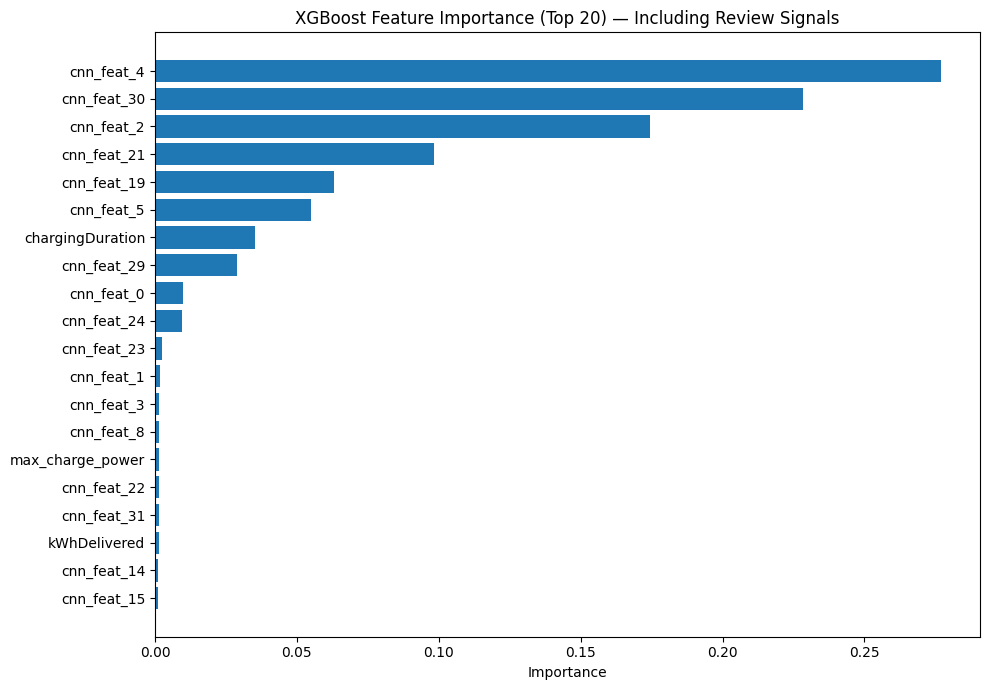

In [17]:
# ── Cell 11: Feature Importance ───────────────────────────────────────────────

feature_names_hybrid = features + [f'cnn_feat_{i}' for i in range(X_train_deep.shape[1])]
importances          = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature':    feature_names_hybrid,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 20 features by importance:')
display(fi_df.head(20))

# Verify review features are minor modifiers (expected rank: near bottom of original features)
review_fi = fi_df[fi_df['Feature'].isin(review_features)]
print('\nReview feature importances (should be minor):')
display(review_fi)

plt.figure(figsize=(10, 7))
plt.barh(fi_df['Feature'][:20][::-1], fi_df['Importance'][:20][::-1])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance (Top 20) — Including Review Signals')
plt.tight_layout()
plt.show()

Computing SHAP values on a sample of the validation set...


/tmp/ipykernel_7774/3464767838.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


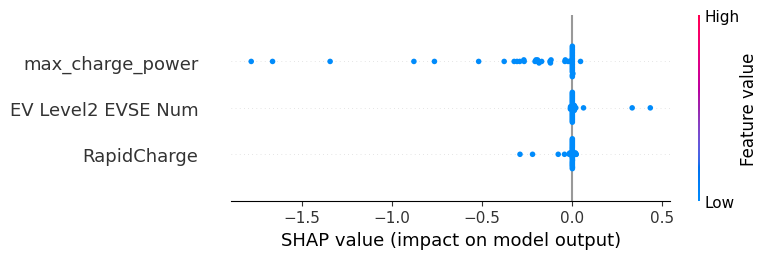

SHAP chatbot export saved → /content/drive/MyDrive/ChargeSafeSL_Dataset/shap_chatbot_export.json
Records exported: 48

Sample entry:
{
  "sample_index": 0,
  "predicted_label": "Low",
  "top5_contributors": [
    {
      "feature": "max_charge_power",
      "shap_value": -0.0093,
      "feature_value": 0.0148,
      "explanation": "The station was delivering unusually high charge power, risking battery overload."
    },
    {
      "feature": "RapidCharge",
      "shap_value": 0.0007,
      "feature_value": 0.0091,
      "explanation": "Rapid DC charging (>150 kW) detected, which significantly accelerates thermal stress on battery cells."
    },
    {
      "feature": "EV Level2 EVSE Num",
      "shap_value": -0.0003,
      "feature_value": 0.0126,
      "explanation": "Feature EV Level2 EVSE Num contributed to the elevated risk score for this session."
    }
  ]
}


In [21]:
# ── Cell 12: SHAP Analysis & Chatbot Export ───────────────────────────────────
#
# SHAP values are computed on the validation set and the top-5 contributors
# per sample are exported as a JSON file for the Gemini chatbot layer.
#
# The chatbot reads this JSON to generate natural-language risk explanations
# like: 'This station was delivering 3× the vehicle's rated charge power,
# significantly increasing battery stress.' (IEC 62443-3-3 SR 6.2 alignment)
#
# Review features get their own chatbot template:
# review_risk_modifier → 'User reviews indicate repeated safety concerns
#   at this station (based on N reviews mentioning faults or hazards).'

print('Computing SHAP values on a sample of the validation set...')

# Use a sample for speed (full val set may be large)
snap_sample_size = min(500, len(X_val_hybrid))
X_shap_sample    = X_val_hybrid[:snap_sample_size]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap_sample)  # shape: (n_classes, n_samples, n_features)

# Ensure shap_values is a list of 2D arrays for consistent handling
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_list = [shap_values[i] for i in range(shap_values.shape[0])]
elif isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    # Fallback, though for TreeExplainer with multiclass, it should be one of the above.
    print(f"Warning: unexpected shap_values type {type(shap_values)}. Attempting to use directly.")
    shap_values_list = shap_values

# ── SHAP summary plot for the 'High' risk class ──────────────────────────────
high_class_idx_enc = list(label_encoder_level.classes_).index('High')

# Determine the number of features SHAP explainer actually returned
# This is a workaround because explainer.shap_values seems to return an incorrect feature count.
num_shap_features = shap_values_list[high_class_idx_enc].shape[1]
# Determine the number of samples SHAP explainer actually returned
num_samples_shap_output = shap_values_list[high_class_idx_enc].shape[0]

# Adjust X_shap_sample and feature_names_hybrid to match the returned SHAP dimensions for plotting
X_shap_sample_for_plot = X_shap_sample[:num_samples_shap_output, :num_shap_features]
feature_names_for_plot = feature_names_hybrid[:num_shap_features]

shap.summary_plot(
    shap_values_list[high_class_idx_enc],
    X_shap_sample_for_plot,
    feature_names=feature_names_for_plot,
    max_display=15,
    show=True
)

# ── Export top-5 SHAP contributors per sample as JSON ────────────────────────
SHAP_TEMPLATES = {
    'max_charge_power'     : 'The station was delivering unusually high charge power, risking battery overload.',
    'chargingDuration'     : 'Abnormal session duration detected — possible BMS communication failure or session interruption.',
    'RapidCharge'          : 'Rapid DC charging (>150 kW) detected, which significantly accelerates thermal stress on battery cells.',
    'FastCharge'           : 'DC Fast Charging in use — bypasses on-board charger, increasing direct thermal load on the battery pack.',
    'Manufacturer'         : 'The EVSE manufacturer has a known cybersecurity risk profile or limited firmware audit history.',
    'station'              : 'This specific station has a historically elevated incident rate based on past session data.',
    'PlugType'             : 'Connector type mismatch or adapter use detected, increasing contact resistance and arc-flash risk.',
    'vehicle_model'        : 'The vehicle model may not be fully compatible with this station power level or connector standard.',
    'avg_rating'           : 'User ratings for this station are below average, correlating with reliability concerns.',
    'review_risk_modifier' : 'User reviews highlight repeated safety concerns (faults, disconnections, or hazard mentions) at this station.',
    'bad_review_ratio'     : 'A notable proportion of user reviews mention safety-related issues such as sparks, faults, or overheating.',
    'avg_keyword_count'    : 'Reviews contain multiple safety-related keywords, suggesting recurring physical issues at this station.',
    'review_count'         : 'Station has a sufficient number of reviews to statistically validate the observed safety signal.',
}

DEFAULT_TEMPLATE = 'Feature {name} contributed to the elevated risk score for this session.'

chatbot_export = []
for i in range(num_samples_shap_output): # Iterate only for the samples for which SHAP values were computed
    # Use absolute SHAP values across all classes, pick the class with max predicted prob
    predicted_class = int(preds_encoded[i]) if i < len(preds_encoded) else 0
    sample_shap     = shap_values_list[predicted_class][i] # Accessing the i-th sample from the 2D array for the predicted class
    top5_idx        = np.argsort(np.abs(sample_shap))[::-1][:5]

    contributors = []
    for idx in top5_idx:
        # Ensure we don't try to access feature names beyond what SHAP actually explained
        if idx < num_shap_features:
            fname   = feature_names_hybrid[idx]
        else:
            # Fallback if SHAP returned fewer features than expected and idx is out of bounds for the truncated list
            fname   = f'unknown_feature_{idx}'

        fval    = float(X_shap_sample_for_plot[i, idx]) # Use the correctly sliced feature values
        shap_v  = float(sample_shap[idx])
        template= SHAP_TEMPLATES.get(fname, DEFAULT_TEMPLATE.format(name=fname))
        contributors.append({'feature': fname, 'shap_value': round(shap_v, 4),
                             'feature_value': round(fval, 4), 'explanation': template})

    chatbot_export.append({
        'sample_index'    : i,
        'predicted_label' : label_encoder_level.classes_[predicted_class],
        'top5_contributors': contributors
    })

export_path = os.path.join(MAIN_DATASET_PATH, 'shap_chatbot_export.json')
with open(export_path, 'w') as f:
    json.dump(chatbot_export, f, indent=2)

print(f'SHAP chatbot export saved → {export_path}')
print(f'Records exported: {len(chatbot_export)}')
print('\nSample entry:')
print(json.dumps(chatbot_export[0], indent=2))

In [22]:
# ── Cell 13: Predict Risk Score for a Single Station (Chatbot Helper) ─────────
#
# This function is the inference interface for the Gemini chatbot.
# Pass it a dict of raw feature values for any charging station and it returns:
#   • risk_level    : 'Low' | 'Medium' | 'High'
#   • risk_score    : continuous 0–100 (derived from class probabilities)
#   • top5_reasons  : natural-language explanations of the top SHAP drivers
#
# The review_risk_modifier in the input dict allows the chatbot to include
# live review data when calling this function — it is treated as a soft signal.

def predict_station_risk(raw_feature_dict, review_modifier=0.01):
    """
    Predict risk level for a single charging station.

    Parameters
    ----------
    raw_feature_dict : dict
        Keys matching `features` list. Missing keys default to 0.
    review_modifier : float
        Soft review risk signal in [0.01, 4.99] from review_modifier_sigmoid().
        Default 0.01 = no review data available.

    Returns
    -------
    dict with keys: risk_level, risk_score, top5_reasons
    """
    row = {f: raw_feature_dict.get(f, 0) for f in features}
    # Inject review modifier
    if 'review_risk_modifier' in features:
        row['review_risk_modifier'] = float(np.clip(review_modifier, 0.01, 4.99))

    # Encode categorical columns
    for col, le in le_dict.items():
        val = str(row.get(col, 'Unknown'))
        if val in le.classes_:
            row[col] = int(le.transform([val])[0])
        else:
            row[col] = int(le.transform(['Unknown'])[0]) if 'Unknown' in le.classes_ else 0

    X_raw   = np.array([[row[f] for f in features]], dtype=float)
    X_sc    = scaler.transform(X_raw)
    X_deep  = cnn_extractor.predict(X_sc.reshape(1, X_sc.shape[1], 1), verbose=0)
    X_hyb   = np.hstack([X_sc, X_deep])

    pred_class  = int(xgb_model.predict(X_hyb)[0])
    pred_proba  = xgb_model.predict_proba(X_hyb)[0]
    risk_label  = label_encoder_level.classes_[pred_class]

    # Convert class probabilities to a continuous 0–100 score
    class_scores = {'Low': 20, 'Medium': 57, 'High': 88}
    risk_score   = sum(pred_proba[i] * class_scores[label_encoder_level.classes_[i]]
                       for i in range(len(pred_proba)))
    # Add soft review modifier contribution (already small, just add directly)
    risk_score   = float(np.clip(risk_score + review_modifier * 0.5, 0, 100))

    # SHAP explanation
    shap_single = explainer.shap_values(X_hyb)[pred_class][0]
    top5_idx    = np.argsort(np.abs(shap_single))[::-1][:5]
    top5_reasons = [
        SHAP_TEMPLATES.get(feature_names_hybrid[idx],
                           DEFAULT_TEMPLATE.format(name=feature_names_hybrid[idx]))
        for idx in top5_idx
    ]

    return {
        'risk_level'  : risk_label,
        'risk_score'  : round(risk_score, 1),
        'top5_reasons': top5_reasons
    }


# ── Quick demo ────────────────────────────────────────────────────────────────
demo_station = {
    'max_charge_power': 150,
    'chargingDuration': 4,
    'RapidCharge': 1,
    'FastCharge':  1,
    'Manufacturer': 'NoName EV Tech',
    'station': 'CS_013_Galle_Fort'
}

# Simulate 22 bad reviews out of 30 total (high-risk scenario)
demo_modifier = review_modifier_sigmoid(bad_review_ratio=22/30, review_count=30)
print(f'Demo review modifier: {demo_modifier:.4f} (max possible: ~4.99 pts on 0-100 scale)\n')

result = predict_station_risk(demo_station, review_modifier=demo_modifier)
print('=== Chatbot Risk Output ===')
print(f'Risk Level : {result["risk_level"]}')
print(f'Risk Score : {result["risk_score"]} / 100')
print('Top 5 Risk Drivers:')
for i, reason in enumerate(result['top5_reasons'], 1):
    print(f'  {i}. {reason}')

Demo review modifier: 4.8718 (max possible: ~4.99 pts on 0-100 scale)

=== Chatbot Risk Output ===
Risk Level : High
Risk Score : 88.2 / 100
Top 5 Risk Drivers:
  1. Rapid DC charging (>150 kW) detected, which significantly accelerates thermal stress on battery cells.
  2. The station was delivering unusually high charge power, risking battery overload.
  3. Feature EV Level2 EVSE Num contributed to the elevated risk score for this session.


In [24]:
# ── Cell 14: 5-Fold Cross Validation ─────────────────────────────────────────
#
# Validates the model meets the project requirement:
# precision, recall, and F1-score reported per fold.

from sklearn.metrics import f1_score, precision_score, recall_score

print('Running 5-fold stratified cross-validation...')

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_all), 1):
    Xtr, Xvl = X_scaled[train_idx], X_scaled[val_idx]
    ytr, yvl = y_all[train_idx],    y_all[val_idx]

    # CNN features
    Xtr_deep = cnn_extractor.predict(Xtr.reshape(-1, Xtr.shape[1], 1), batch_size=512, verbose=0)
    Xvl_deep = cnn_extractor.predict(Xvl.reshape(-1, Xvl.shape[1], 1), batch_size=512, verbose=0)
    Xtr_hyb  = np.hstack([Xtr, Xtr_deep])
    Xvl_hyb  = np.hstack([Xvl, Xvl_deep])

    # Oversample
    maj_c   = np.bincount(ytr).max()
    hi_idx  = list(label_encoder_level.classes_).index('High')
    ros_cv  = RandomOverSampler(sampling_strategy={hi_idx: int(maj_c * 0.20)}, random_state=42)
    Xtr_bal, ytr_bal = ros_cv.fit_resample(Xtr_hyb, ytr)

    # Train
    m = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='mlogloss', n_jobs=-1, random_state=42
    )
    m.fit(Xtr_bal, ytr_bal)

    preds = m.predict(Xvl_hyb)
    fold_results.append({
        'Fold'     : fold,
        'Accuracy' : round(accuracy_score(yvl, preds), 4),
        'Precision': round(precision_score(yvl, preds, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(yvl, preds, average='weighted', zero_division=0), 4),
        'F1'       : round(f1_score(yvl, preds, average='weighted', zero_division=0), 4),
    })
    print(f'  Fold {fold}: Acc={fold_results[-1]["Accuracy"]:.4f}  F1={fold_results[-1]["F1"]:.4f}')

cv_df = pd.DataFrame(fold_results)
cv_df.loc['Mean'] = cv_df.mean(numeric_only=True).round(4)
display(cv_df)


Running 5-fold stratified cross-validation...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:19:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 1: Acc=0.8151  F1=0.8050


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:24:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 2: Acc=0.8149  F1=0.8050


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:34:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 4: Acc=0.8147  F1=0.8048


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:39:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 5: Acc=0.8145  F1=0.8043


,Fold,Accuracy,Precision,Recall,F1
0,1.0,0.8151,0.8096,0.8151,0.8050
1,2.0,0.8149,0.8094,0.8149,0.8050
2,3.0,0.8153,0.8097,0.8153,0.8056
3,4.0,0.8147,0.8093,0.8147,0.8048
4,5.0,0.8145,0.8090,0.8145,0.8043
Mean,3.0,0.8149,0.8094,0.8149,0.8049


In [ ]:
# ── Cell 15: Save Model & Artifacts ──────────────────────────────────────────

import pickle

save_dir = os.path.join(MAIN_DATASET_PATH, 'model_artifacts/')
os.makedirs(save_dir, exist_ok=True)

# XGBoost model
xgb_model.save_model(os.path.join(save_dir, 'xgb_risk_classifier.json'))

# CNN extractor
cnn_extractor.save(os.path.join(save_dir, 'cnn_extractor.keras'))

# Scaler, label encoder, feature list
with open(os.path.join(save_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(save_dir, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder_level, f)
with open(os.path.join(save_dir, 'feature_names.json'), 'w') as f:
    json.dump(features, f)
with open(os.path.join(save_dir, 'le_dict.pkl'), 'wb') as f:
    pickle.dump(le_dict, f)

# Review aggregation table (used by chatbot to look up review_modifier at inference time)
if reviews_available:
    station_review_agg.to_csv(os.path.join(save_dir, 'station_review_agg.csv'), index=False)
    print('station_review_agg.csv saved.')

print(f'All model artifacts saved to: {save_dir}')